In [1]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist, fashion_mnist
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

2025-10-05 10:48:20.711662: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#define the autoencoder model
input_layer = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_layer)
bottleneck = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(bottleneck)
output_layer = Dense(784, activation = 'sigmoid')(decoded)
autoencoder = Model(input_layer, output_layer)


I0000 00:00:1759641504.846865   20822 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1811 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [3]:
#load and preprocess the data mnist
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28 * 28)


In [4]:
#compile the dr model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

#train the autoencoder
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True,
                validation_split=0.2)

Epoch 1/50


2025-10-05 10:48:26.695939: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f0dd40072e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-05 10:48:26.695959: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-10-05 10:48:26.713631: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-05 10:48:26.858459: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


 92/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4744

I0000 00:00:1759641507.821887   24875 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.3855 - val_loss: 0.1837
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1736 - val_loss: 0.1475
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1427 - val_loss: 0.1337
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1309 - val_loss: 0.1258
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1231 - val_loss: 0.1189
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1170 - val_loss: 0.1143
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1128 - val_loss: 0.1112
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1097 - val_loss: 0.1088
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1075 - val_loss: 0.1067
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1056 - val_loss: 0.1052
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1037 - val_loss: 0.1037
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


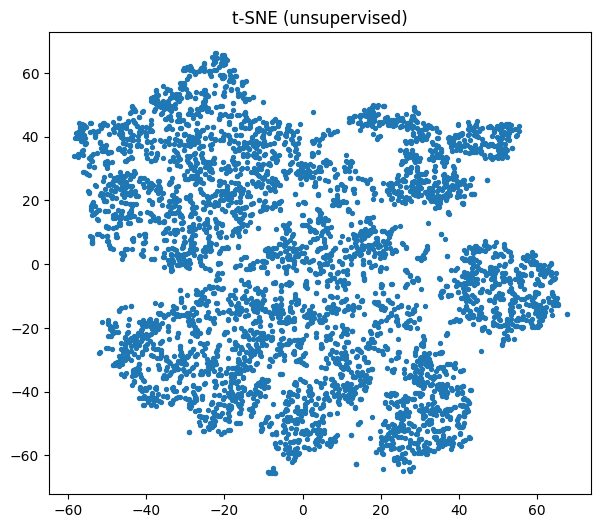

In [9]:
#evaluating the dimensionality reduction model (unsupervised)
encoder = Model(input_layer, bottleneck)
compressed_data = encoder.predict(x_train, batch_size=256)

subset_size = min(5000, len(compressed_data))
idx = np.random.choice(len(compressed_data), size=subset_size, replace=False)
compressed_subset = compressed_data[idx]

tsne = TSNE(n_components=2, init='random', learning_rate='auto', perplexity=30)
compressed_2d = tsne.fit_transform(compressed_subset)

plt.figure(figsize=(7,6))
plt.scatter(compressed_2d[:, 0], compressed_2d[:, 1], s=8)
plt.title("t-SNE (unsupervised)")
plt.show()
